# 1D Linear Poisson-Boltzmann Benchmark

This notebook validates the **linearized** Poisson-Boltzmann (PB) model in 1D.

## Model
For a symmetric electrolyte, the linear PB equation is:

$$
\frac{d^2 \phi}{dx^2} = \kappa^2 \phi
$$

where $\phi$ is electric potential and $\kappa^{-1}$ is the Debye length.

## Assumptions
- Small-potential regime: $|z e \phi / (k_B T)| \ll 1$
- Dilute electrolyte and continuum mean-field description
- 1D geometry for benchmark comparison
- Fixed boundary conditions set in the input cells

> Use this notebook when you want a fast, near-equilibrium reference solution.

## What to check in results
- Potential decays approximately exponentially away from charged boundaries
- Numerical profile is smooth and monotonic under standard conditions
- Parameter changes mainly rescale decay length and potential magnitude

In [1]:
import unxt
import quaxed.numpy as jnp

import matplotlib.pyplot as plt

In [2]:
from fdm_edl.api import ElectricalDoubleLayer
from fdm_edl.benchmark import LinearPoissonBoltzmann

In [3]:
# 0.01 M 1-1 electrolyte, T = 298 K, epsilon_r = 78.5
edl_obj = ElectricalDoubleLayer("input.json")
x = unxt.Quantity(jnp.linspace(0, 50.0, 500), unit="nm")
# sigma = _constants.ELEMENTARY_CHARGE / unxt.Quantity(1e4, "angstrom^2")
phi0 = unxt.Quantity(0.025, "V")

linear_pb = LinearPoissonBoltzmann(edl_obj=edl_obj)
linear_pb.compute(x, phi0)

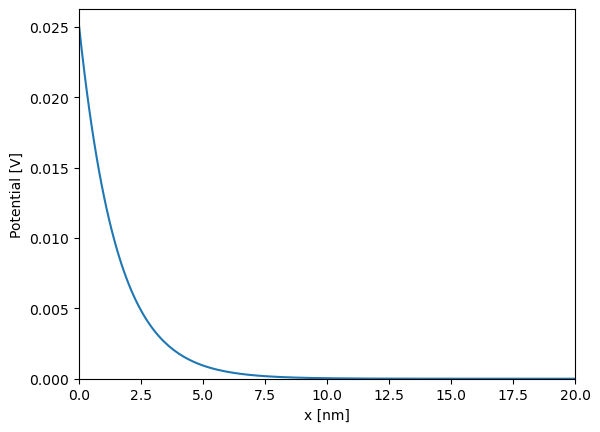

In [4]:
fig, ax = plt.subplots()

# potential in V
ax.plot(x.to("nm"), linear_pb.edl_status.phi.to("V"))

ax.set_xlim(0, 20)
ax.set_ylim(bottom=0.0)
ax.set_xlabel("x [nm]")
ax.set_ylabel("Potential [V]")

plt.show()

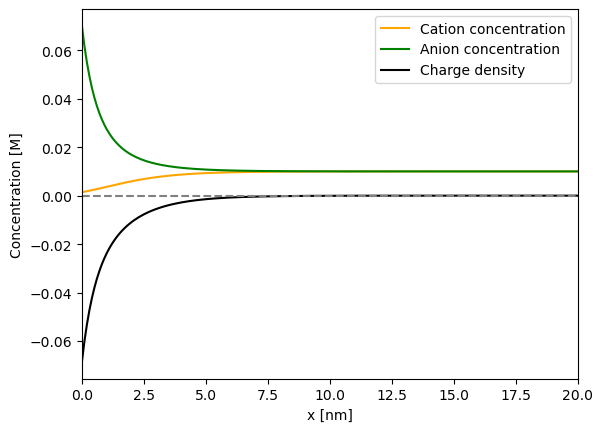

In [5]:
fig, ax = plt.subplots()

# ion conc in mol/L
c_cation = linear_pb.edl_status.ion_conc["Ca"]
c_anion = linear_pb.edl_status.ion_conc["SO4"]

ax.plot(x.to("nm"), c_cation, color="orange", label="Cation concentration")
ax.plot(x.to("nm"), c_anion, color="green", label="Anion concentration")
ax.plot(x.to("nm"), c_cation - c_anion, color="k", label="Charge density")

ax.axhline(0.0, color="gray", linestyle="dashed")

ax.set_xlim(0, 20)
ax.set_xlabel("x [nm]")
ax.set_ylabel("Concentration [M]")
ax.legend()

plt.show()